# EDA - Blood Group Detection Dataset

Notebook này dùng để khám phá nhanh dataset COCO từ Roboflow trước khi bước sang feature extraction và classification.

Mục tiêu chính:
- Hiểu cấu trúc `train`, `valid`, `test`.
- Kiểm tra phân bố nhóm máu suy ra từ tên file.
- Kiểm tra annotation `A`, `B`, `D` trong COCO JSON.
- Kiểm tra bbox có hợp lệ và có phù hợp để crop đặc trưng không.
- Tạo bảng feature sơ bộ từ các crop làm cầu nối sang classification.

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

ROOT = Path.cwd()
SPLITS = ["train", "valid", "test"]
OUTPUT_DIR = ROOT / "eda_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

ROOT

WindowsPath('e:/LUT/PatternRecognition/Final/Blood Group Detection.coco')

## 1. Load COCO JSON

Mỗi split có một file `_annotations.coco.json`. File này chứa danh sách ảnh, danh sách bbox, và category `A`, `B`, `D`.

In [2]:
def parse_blood_group(name: str) -> str:
    """Extract A+, A-, B+, B-, AB+, AB-, O+, O- from the beginning of a filename."""
    match = re.match(r"^(AB|A|B|O)[+-]", name)
    return match.group(0) if match else "UNKNOWN"


def load_coco(split: str) -> dict:
    path = ROOT / split / "_annotations.coco.json"
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def build_tables():
    image_rows = []
    annotation_rows = []

    for split in SPLITS:
        data = load_coco(split)
        categories = {cat["id"]: cat["name"] for cat in data["categories"]}
        images = {img["id"]: img for img in data["images"]}

        for img in data["images"]:
            original_name = img.get("extra", {}).get("name", img["file_name"])
            blood_group = parse_blood_group(original_name)
            image_rows.append({
                "split": split,
                "image_id": img["id"],
                "file_name": img["file_name"],
                "original_name": original_name,
                "blood_group": blood_group,
                "abo": blood_group[:-1] if blood_group != "UNKNOWN" else "UNKNOWN",
                "rh": blood_group[-1] if blood_group != "UNKNOWN" else "UNKNOWN",
                "width": img["width"],
                "height": img["height"],
                "image_area": img["width"] * img["height"],
                "image_path": str(ROOT / split / img["file_name"]),
            })

        for ann in data["annotations"]:
            img = images[ann["image_id"]]
            original_name = img.get("extra", {}).get("name", img["file_name"])
            blood_group = parse_blood_group(original_name)
            x, y, w, h = ann["bbox"]
            image_area = img["width"] * img["height"]
            annotation_rows.append({
                "split": split,
                "annotation_id": ann["id"],
                "image_id": ann["image_id"],
                "file_name": img["file_name"],
                "original_name": original_name,
                "blood_group": blood_group,
                "category_id": ann["category_id"],
                "category_name": categories.get(ann["category_id"], "UNKNOWN"),
                "bbox_x": x,
                "bbox_y": y,
                "bbox_w": w,
                "bbox_h": h,
                "bbox_area": w * h,
                "bbox_area_ratio": (w * h) / image_area if image_area else np.nan,
                "image_width": img["width"],
                "image_height": img["height"],
                "image_path": str(ROOT / split / img["file_name"]),
            })

    return pd.DataFrame(image_rows), pd.DataFrame(annotation_rows)


images_df, anns_df = build_tables()

images_df.head(), anns_df.head()

(   split  image_id                                 file_name original_name blood_group abo rh  width  height  image_area  \
 0  train         0    B- (8)_jpg.rf.Y4gSPakmKnxXtqrN20gd.jpg    B- (8).jpg          B-   B  -   2644     868     2294992   
 1  train         1  AB- (59)_jpg.rf.XqNFkV6f7JNjc2LlN7za.jpg  AB- (59).jpg         AB-  AB  -    991     302      299282   
 2  train         2    A+ (7)_jpg.rf.YMFIioqVqZGqD5EMeCtF.jpg    A+ (7).jpg          A+   A  +   1995     607     1210965   
 3  train         3   A+ (14)_jpg.rf.sSksp3LBJpQi1ohZIjYl.jpg   A+ (14).jpg          A+   A  +   2538     768     1949184   
 4  train         4   B- (95)_jpg.rf.Y9dEJiYDftKo36eOzT7I.jpg   B- (95).jpg          B-   B  -   1019     341      347479   
 
                                           image_path  
 0  e:\LUT\PatternRecognition\Final\Blood Group De...  
 1  e:\LUT\PatternRecognition\Final\Blood Group De...  
 2  e:\LUT\PatternRecognition\Final\Blood Group De...  
 3  e:\LUT\PatternRecogn

## 2. Dataset overview

Bảng này cho biết mỗi split có bao nhiêu ảnh và bao nhiêu bbox annotation.

In [3]:
overview = (
    images_df.groupby("split")
    .agg(
        images=("file_name", "count"),
        blood_groups=("blood_group", "nunique"),
        min_width=("width", "min"),
        max_width=("width", "max"),
        min_height=("height", "min"),
        max_height=("height", "max"),
    )
    .join(anns_df.groupby("split").agg(annotations=("annotation_id", "count")))
    .reset_index()
)

overview

,split,images,blood_groups,min_width,max_width,min_height,max_height,annotations
0,test,240,3,1096,3159,460,1388,383
1,train,1386,8,265,3790,82,2082,2157
2,valid,446,4,347,3773,107,1325,998


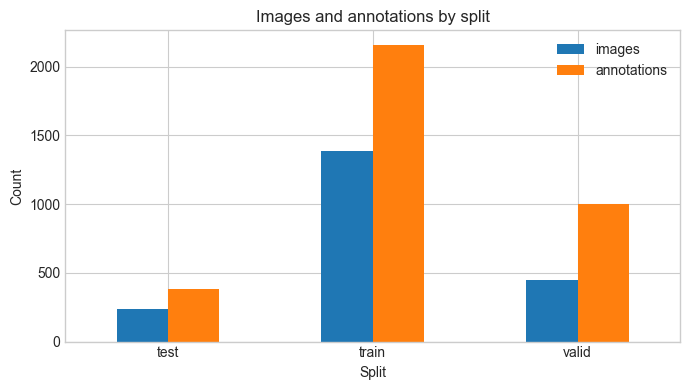

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
overview.set_index("split")[["images", "annotations"]].plot(kind="bar", ax=ax)
ax.set_title("Images and annotations by split")
ax.set_xlabel("Split")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Blood group distribution from filenames

COCO category chỉ là vùng `A`, `B`, `D`. Nhóm máu đầy đủ như `A+`, `AB-`, `O+` được suy ra từ tên file.

In [5]:
blood_counts = pd.crosstab(images_df["blood_group"], images_df["split"])
blood_counts = blood_counts.reindex(sorted(blood_counts.index))
blood_counts

split,test,train,valid
blood_group,,,
A+,1,299,0
A-,168,128,0
AB+,71,110,111
AB-,0,100,185
B+,0,150,149
B-,0,298,0
O+,0,299,0
O-,0,2,1


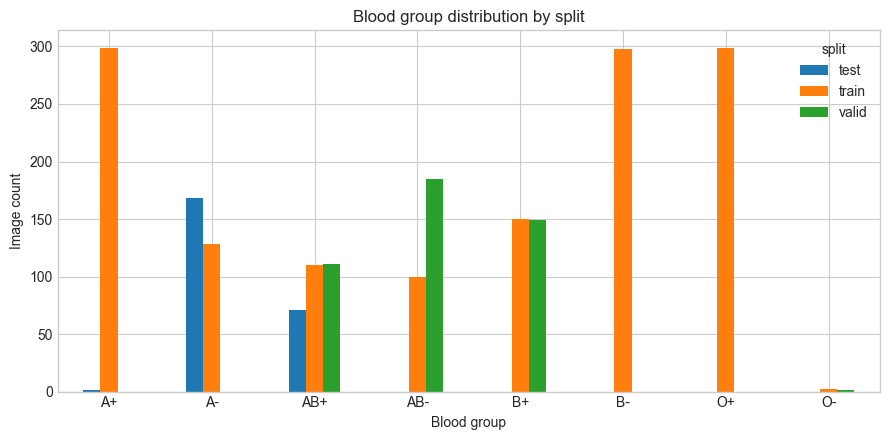

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
blood_counts.plot(kind="bar", ax=ax)
ax.set_title("Blood group distribution by split")
ax.set_xlabel("Blood group")
ax.set_ylabel("Image count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. COCO annotation distribution: A, B, D

Các category này tương ứng với vùng thuốc thử/ô phản ứng cần crop để đo đặc trưng.

In [7]:
ann_counts = pd.crosstab(anns_df["category_name"], anns_df["split"])
ann_counts = ann_counts.reindex(["A", "B", "D"])
ann_counts

split,test,train,valid
category_name,,,
A,239,640,297
B,71,660,442
D,73,857,259


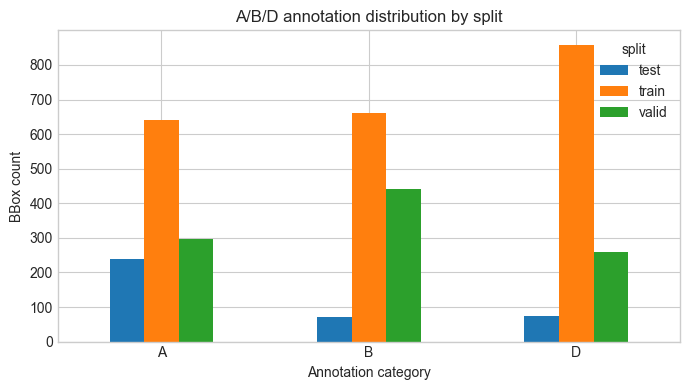

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ann_counts.plot(kind="bar", ax=ax)
ax.set_title("A/B/D annotation distribution by split")
ax.set_xlabel("Annotation category")
ax.set_ylabel("BBox count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Compare expected vs observed A/B/D regions

Dựa theo tên nhóm máu, ta biết vùng nào thường được annotation:

- `A+`: A, D
- `A-`: A
- `B+`: B, D
- `B-`: B
- `AB+`: A, B, D
- `AB-`: A, B
- `O+`: D
- `O-`: không có A/B/D dương tính

Phần này giúp phát hiện ảnh thiếu bbox, dư bbox, hoặc split bị lệch.

In [9]:
EXPECTED_REACTIONS = {
    "A+": {"A", "D"},
    "A-": {"A"},
    "B+": {"B", "D"},
    "B-": {"B"},
    "AB+": {"A", "B", "D"},
    "AB-": {"A", "B"},
    "O+": {"D"},
    "O-": set(),
}

observed = (
    anns_df[anns_df["category_name"].isin(["A", "B", "D"])]
    .groupby(["split", "image_id"])["category_name"]
    .apply(list)
    .reset_index(name="observed_categories")
)

completeness = images_df.merge(observed, on=["split", "image_id"], how="left")
completeness["observed_categories"] = completeness["observed_categories"].apply(lambda x: x if isinstance(x, list) else [])
completeness["observed_set"] = completeness["observed_categories"].apply(lambda x: tuple(sorted(set(x))))
completeness["expected_set"] = completeness["blood_group"].map(lambda x: tuple(sorted(EXPECTED_REACTIONS.get(x, set()))))
completeness["has_duplicate_category"] = completeness["observed_categories"].apply(lambda x: len(x) != len(set(x)))
completeness["matches_expected"] = completeness["observed_set"] == completeness["expected_set"]

quality_summary = completeness.groupby("split").agg(
    images=("file_name", "count"),
    matches_expected=("matches_expected", "sum"),
    duplicate_category_images=("has_duplicate_category", "sum"),
).reset_index()
quality_summary["match_rate"] = quality_summary["matches_expected"] / quality_summary["images"]
quality_summary

,split,images,matches_expected,duplicate_category_images,match_rate
0,test,240,239,0,0.995833
1,train,1386,1371,5,0.989177
2,valid,446,442,1,0.991031


In [10]:
pattern_counts = (
    completeness.assign(observed_pattern=completeness["observed_set"].apply(lambda x: "+".join(x) if x else "none"))
    .groupby(["split", "blood_group", "observed_pattern"])
    .size()
    .reset_index(name="count")
    .sort_values(["split", "blood_group", "count"], ascending=[True, True, False])
)

pattern_counts.head(30)

,split,blood_group,observed_pattern,count
0,test,A+,A+D,1
1,test,A-,A,167
2,test,A-,D,1
3,test,AB+,A+B+D,71
6,train,A+,A+D,295
7,train,A+,B+D,2
4,train,A+,A,1
5,train,A+,A+B+D,1
8,train,A-,A,127
9,train,A-,A+D,1


## 6. Image size and bbox size

Feature extraction sẽ phụ thuộc vào crop. Vì vậy cần xem kích thước ảnh và bbox có quá nhỏ/quá lớn hoặc bất thường không.

In [11]:
bbox_validity = anns_df.assign(
    bbox_valid=(anns_df["bbox_x"] >= 0)
    & (anns_df["bbox_y"] >= 0)
    & (anns_df["bbox_w"] > 0)
    & (anns_df["bbox_h"] > 0)
    & (anns_df["bbox_x"] + anns_df["bbox_w"] <= anns_df["image_width"] + 1)
    & (anns_df["bbox_y"] + anns_df["bbox_h"] <= anns_df["image_height"] + 1)
)

bbox_stats = anns_df.groupby("split").agg(
    bbox_area_min=("bbox_area", "min"),
    bbox_area_median=("bbox_area", "median"),
    bbox_area_max=("bbox_area", "max"),
    bbox_area_ratio_median=("bbox_area_ratio", "median"),
).join(bbox_validity.groupby("split").agg(invalid_bboxes=("bbox_valid", lambda s: (~s).sum())))

bbox_stats

,bbox_area_min,bbox_area_median,bbox_area_max,bbox_area_ratio_median,invalid_bboxes
split,,,,,
test,79524.5808,278239.0824,705218.5325,0.166499,0
train,4755.9611,244141.2943,824781.1826,0.183364,0
valid,4825.7913,180746.8677,895617.4889,0.178715,0


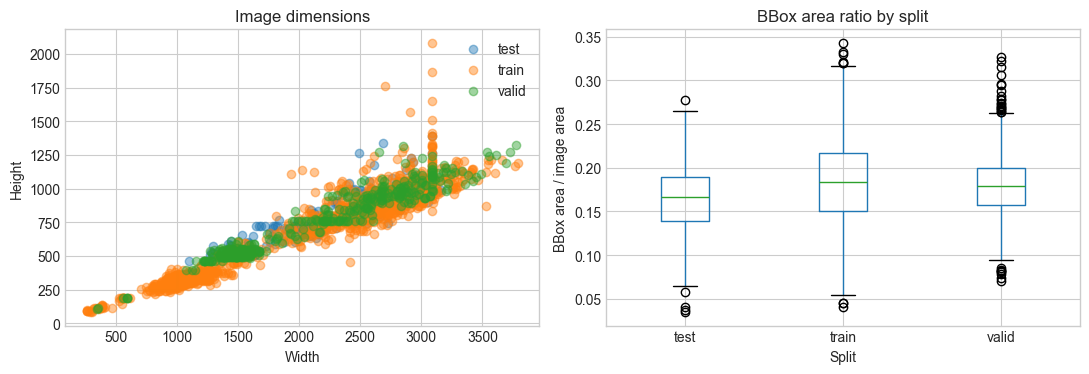

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for split, group in images_df.groupby("split"):
    axes[0].scatter(group["width"], group["height"], alpha=0.45, label=split)
axes[0].set_title("Image dimensions")
axes[0].set_xlabel("Width")
axes[0].set_ylabel("Height")
axes[0].legend()

anns_df.boxplot(column="bbox_area_ratio", by="split", ax=axes[1])
axes[1].set_title("BBox area ratio by split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("BBox area / image area")
fig.suptitle("")

plt.tight_layout()
plt.show()

## 7. Visualize sample images with bboxes

Dùng phần này để kiểm tra trực quan bbox có đúng vùng phản ứng không.

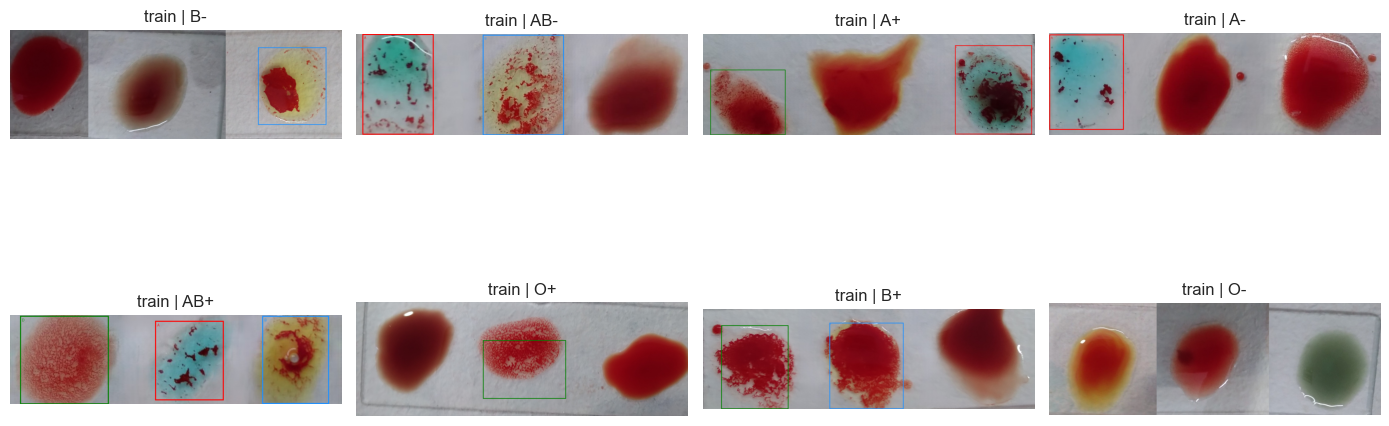

In [13]:
COLORS = {"A": "red", "B": "dodgerblue", "D": "green"}


def draw_annotations(sample_row):
    image = Image.open(sample_row["image_path"]).convert("RGB")
    draw = ImageDraw.Draw(image)
    rows = anns_df[(anns_df["split"] == sample_row["split"]) & (anns_df["image_id"] == sample_row["image_id"])]
    for _, ann in rows.iterrows():
        x, y, w, h = ann[["bbox_x", "bbox_y", "bbox_w", "bbox_h"]]
        color = COLORS.get(ann["category_name"], "yellow")
        draw.rectangle([x, y, x + w, y + h], outline=color, width=max(3, image.width // 400))
        draw.text((x + 5, y + 5), ann["category_name"], fill=color)
    return image


samples = (
    images_df[images_df["blood_group"].isin(["A+", "B+", "AB+", "O+", "A-", "B-", "AB-", "O-"])]
    .groupby("blood_group", group_keys=False)
    .head(1)
)

cols = 4
rows = int(np.ceil(len(samples) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(14, 3.6 * rows))
axes = np.array(axes).reshape(-1)

for ax, (_, sample) in zip(axes, samples.iterrows()):
    ax.imshow(draw_annotations(sample))
    ax.set_title(f"{sample['split']} | {sample['blood_group']}")
    ax.axis("off")

for ax in axes[len(samples):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 8. Starter feature extraction from cropped A/B/D regions

Cell này chưa phải mô hình classification hoàn chỉnh. Nó tạo bảng đặc trưng cơ bản từ mỗi bbox crop để chuẩn bị cho bước sau.

Các feature ban đầu gồm:
- Mean/std RGB.
- Mean/std grayscale.
- Edge density đơn giản dựa trên gradient.
- Bbox geometry.

In [14]:
def crop_bbox(image: Image.Image, bbox):
    x, y, w, h = bbox
    left = max(0, int(round(x)))
    top = max(0, int(round(y)))
    right = min(image.width, int(round(x + w)))
    bottom = min(image.height, int(round(y + h)))
    return image.crop((left, top, right, bottom))


def extract_crop_features(crop: Image.Image) -> dict:
    arr = np.asarray(crop.convert("RGB"), dtype=np.float32)
    gray = arr.mean(axis=2)
    gy, gx = np.gradient(gray)
    grad_mag = np.sqrt(gx ** 2 + gy ** 2)
    threshold = np.percentile(grad_mag, 75) if grad_mag.size else 0

    return {
        "r_mean": arr[:, :, 0].mean(),
        "g_mean": arr[:, :, 1].mean(),
        "b_mean": arr[:, :, 2].mean(),
        "r_std": arr[:, :, 0].std(),
        "g_std": arr[:, :, 1].std(),
        "b_std": arr[:, :, 2].std(),
        "gray_mean": gray.mean(),
        "gray_std": gray.std(),
        "edge_density": float((grad_mag > threshold).mean()) if grad_mag.size else np.nan,
    }


feature_rows = []
for _, ann in anns_df.iterrows():
    image = Image.open(ann["image_path"]).convert("RGB")
    crop = crop_bbox(image, ann[["bbox_x", "bbox_y", "bbox_w", "bbox_h"]].tolist())
    features = extract_crop_features(crop)
    feature_rows.append({
        "split": ann["split"],
        "file_name": ann["file_name"],
        "blood_group": ann["blood_group"],
        "category_name": ann["category_name"],
        "bbox_area_ratio": ann["bbox_area_ratio"],
        **features,
    })

crop_features_df = pd.DataFrame(feature_rows)
crop_features_df.to_csv(OUTPUT_DIR / "crop_level_features.csv", index=False)
crop_features_df.head()

,split,file_name,blood_group,category_name,bbox_area_ratio,r_mean,g_mean,b_mean,r_std,g_std,b_std,gray_mean,gray_std,edge_density
0,train,B- (8)_jpg.rf.Y4gSPakmKnxXtqrN20gd.jpg,B-,B,0.146105,162.091797,129.144623,107.638176,19.651550,61.124416,53.500786,132.958237,43.516975,0.249361
1,train,AB- (59)_jpg.rf.XqNFkV6f7JNjc2LlN7za.jpg,AB-,A,0.213270,118.996902,146.875076,144.921295,38.509953,27.268394,26.323336,136.931091,26.804707,0.249765
2,train,AB- (59)_jpg.rf.XqNFkV6f7JNjc2LlN7za.jpg,AB-,B,0.242699,156.558578,124.718239,109.182770,14.356998,41.686024,42.521423,130.153198,31.214203,0.250000
3,train,A+ (7)_jpg.rf.YMFIioqVqZGqD5EMeCtF.jpg,A+,D,0.146112,132.675537,80.721916,79.949486,19.275665,56.340153,55.124180,97.782310,42.718666,0.249968
4,train,A+ (7)_jpg.rf.YMFIioqVqZGqD5EMeCtF.jpg,A+,A,0.203826,100.696487,104.385155,104.726738,41.639877,54.888260,54.759880,103.269463,49.393410,0.245904


## 9. Save EDA tables

Lưu các bảng trung gian để dùng cho báo cáo hoặc bước classification.

In [15]:
images_df.to_csv(OUTPUT_DIR / "images_table.csv", index=False)
anns_df.to_csv(OUTPUT_DIR / "annotations_table.csv", index=False)
overview.to_csv(OUTPUT_DIR / "overview.csv", index=False)
blood_counts.to_csv(OUTPUT_DIR / "blood_group_counts.csv")
ann_counts.to_csv(OUTPUT_DIR / "annotation_counts.csv")
quality_summary.to_csv(OUTPUT_DIR / "quality_summary.csv", index=False)
pattern_counts.to_csv(OUTPUT_DIR / "observed_patterns.csv", index=False)

sorted(p.name for p in OUTPUT_DIR.glob("*.csv"))

['annotation_counts.csv',
 'annotations_table.csv',
 'blood_group_counts.csv',
 'crop_level_features.csv',
 'images_table.csv',
 'observed_patterns.csv',
 'overview.csv',
 'quality_summary.csv']

## 10. Key observations for report

- Dataset gốc đang đúng cấu trúc COCO, không cần move ảnh sang folder `A+`, `A-`, ...
- Nhóm máu đầy đủ có thể lấy từ tên file, còn JSON cho biết bbox của vùng `A`, `B`, `D`.
- Split hiện tại không cân bằng theo nhóm máu. Đặc biệt `valid` và `test` chỉ chứa một vài nhóm máu, nên metric classification cuối cùng có thể bị lệch.
- Bbox hợp lệ và có thể dùng để crop vùng phản ứng.
- Bước tiếp theo nên là xây dựng feature theo từng ảnh bằng cách gom feature của các crop `A`, `B`, `D`, rồi train classifier truyền thống như SVM, Random Forest, KNN hoặc Logistic Regression.